# EDA — Pobreza Municipal 2020
**Fuente:** CONEVAL · `data/raw/pobreza_municipal_2020.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white",
                     "axes.facecolor": "white", "font.size": 11})

DATA_RAW = Path("../data/raw")

df = pd.read_csv(DATA_RAW / "pobreza_municipal_2020.csv", encoding="latin-1")

# Limpiar columnas numéricas (miles con coma)
cols_id = ["clave_entidad", "entidad_federativa", "clave_municipio", "municipio"]
for col in df.columns:
    if col not in cols_id:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", "").str.strip(), errors="coerce"
        )

# Construir CVEGEO
df["CVEGEO"] = (df["clave_entidad"].astype(str).str.zfill(2) +
                df["clave_municipio"].astype(str).str.zfill(3))

print(f"Forma: {df.shape}")
df.head(3)

Forma: (2469, 38)


,clave_entidad,entidad_federativa,clave_municipio,municipio,poblacion,pobreza,pobreza_pob,pobreza_e,pobreza_e_pob,pobreza_m,...,ic_ali_pob,carencias,carencias_pob,carencias3,carencias3_pob,plp,plp_pob,plp_e,plp_e_pob,CVEGEO
0,1,Aguascalientes,1001,Aguascalientes,922268.0,23.7,218414.0,2.0,18206.0,21.7,...,145444.0,51.6,475558.0,7.2,66231.0,33.7,310444.0,9.0,82866.0,011001
1,1,Aguascalientes,1002,Asientos,48635.0,40.1,19518.0,4.1,2015.0,36.0,...,13870.0,79.7,38761.0,15.7,7650.0,46.8,22737.0,15.8,7683.0,011002
2,1,Aguascalientes,1003,Calvillo,52377.0,45.8,23966.0,4.5,2356.0,41.3,...,10552.0,86.2,45164.0,14.4,7520.0,49.5,25935.0,16.0,8380.0,011003


In [2]:
from pathlib import Path

# ── Carpeta de figuras (Cookiecutter: reports/figures/) ──────────────
FIGURES_DIR = Path("../reports/figures/pobreza")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figuras se guardarán en: {FIGURES_DIR.resolve()}")

Figuras se guardarán en: /home/dreamlap/Documents/UNISON/maestria/semestre 2 /AAA/proyecto_AAA_2026-1_equipo4/reports/figures/pobreza


## 1. Información general

In [3]:
print("─" * 55)
print(f"  Municipios totales : {len(df):,}")
print(f"  Columnas           : {df.shape[1]}")
print(f"  Filas con nulos    : {df['pobreza'].isnull().sum()}")
print("─" * 55)

nulos = df[df["pobreza"].isnull()][["entidad_federativa","municipio"]]
print("\nMunicipios con datos faltantes:")
display(nulos)

display(df[["pobreza","pobreza_e","pobreza_m","vul_car","vul_ing","npnv"]].describe().round(2))

───────────────────────────────────────────────────────
  Municipios totales : 2,469
  Columnas           : 38
  Filas con nulos    : 3
───────────────────────────────────────────────────────

Municipios con datos faltantes:


,entidad_federativa,municipio
33,Campeche,Seybaplaya
205,Chiapas,Honduras de la Sierra
2080,Tlaxcala,La Magdalena Tlaltelulco


,pobreza,pobreza_e,pobreza_m,vul_car,vul_ing,npnv
count,2466.0,2466.00,2466.00,2466.00,2466.00,2466.00
mean,62.0,17.24,44.77,25.06,3.94,8.99
std,21.9,15.32,12.28,13.89,3.73,9.75
min,5.5,0.00,5.20,0.00,0.00,0.00
25%,45.6,5.40,37.30,14.80,1.10,1.70
50%,62.7,12.55,46.00,24.30,2.70,5.40
75%,80.3,24.28,53.00,33.90,5.70,13.00
max,99.6,84.40,85.00,77.60,23.60,57.40


## 2. Variables del dataset

| Columna | Descripción |
|---|---|
| `pobreza` | % en pobreza |
| `pobreza_e` | % en pobreza extrema |
| `pobreza_m` | % en pobreza moderada |
| `vul_car` | % vulnerable por carencias sociales |
| `vul_ing` | % vulnerable por ingresos |
| `npnv` | % no pobre y no vulnerable |
| `ic_rezedu` | Rezago educativo |
| `ic_asalud` | Carencia acceso a salud |
| `ic_segsoc` | Carencia seguridad social |
| `ic_cv` | Carencia calidad vivienda |
| `ic_sbv` | Carencia servicios básicos vivienda |
| `ic_ali` | Carencia alimentaria |
| `plp` | % bajo línea de pobreza por ingresos |
| `plp_e` | % bajo línea de pobreza extrema |

## 3. Distribución de pobreza y pobreza extrema

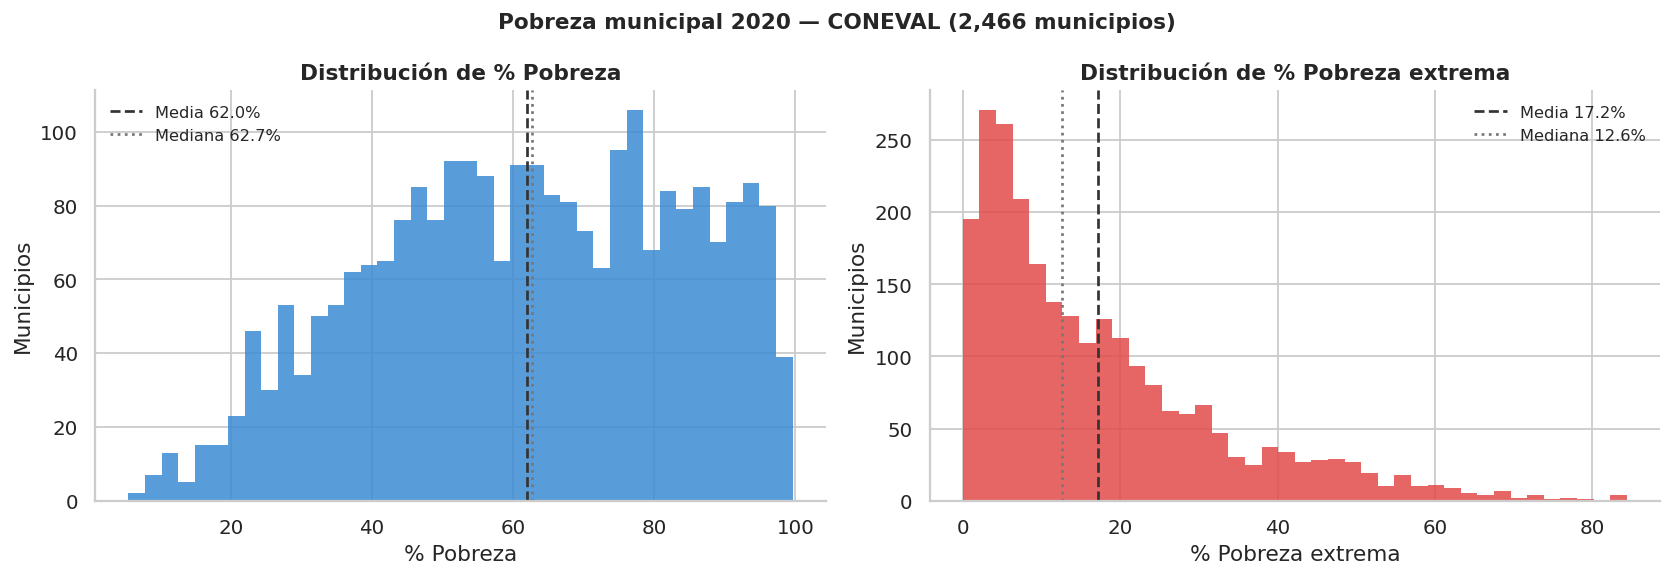

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col, label, color in zip(
    axes,
    ["pobreza", "pobreza_e"],
    ["% Pobreza", "% Pobreza extrema"],
    ["#3B8BD4", "#E24B4A"]
):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(data.mean(),   color="#333", lw=1.5, ls="--",
               label=f"Media {data.mean():.1f}%")
    ax.axvline(data.median(), color="#777", lw=1.5, ls=":",
               label=f"Mediana {data.median():.1f}%")
    ax.set_xlabel(label)
    ax.set_ylabel("Municipios")
    ax.set_title(f"Distribución de {label}", fontweight="bold")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Pobreza municipal 2020 — CONEVAL (2,466 municipios)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_pob_01_distribucion.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Desglose de las 6 carencias sociales

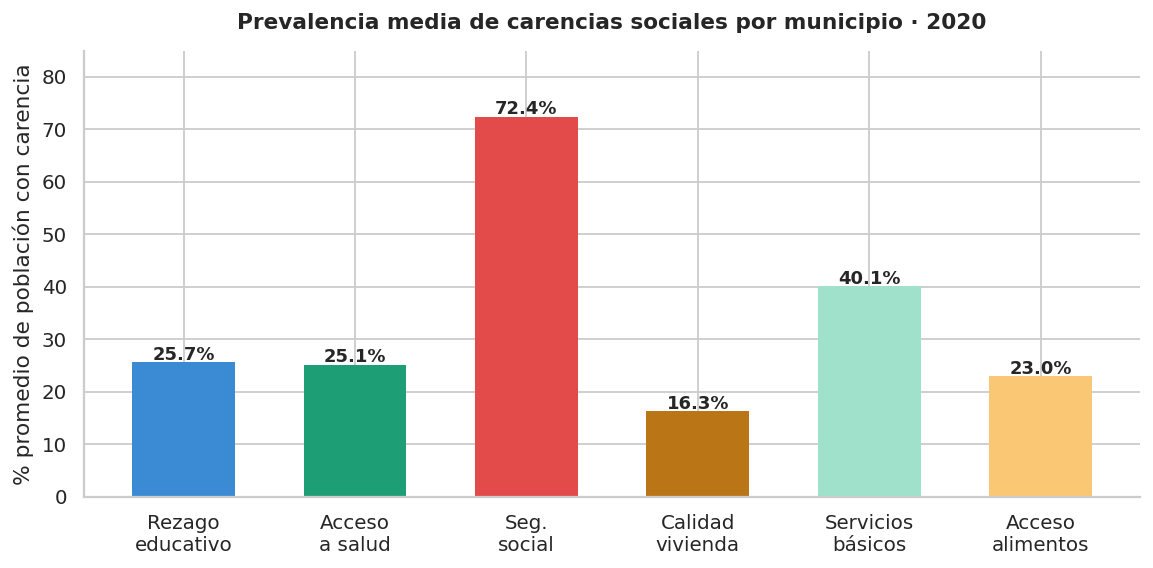

In [5]:
carencias = ["ic_rezedu","ic_asalud","ic_segsoc","ic_cv","ic_sbv","ic_ali"]
labels_c  = ["Rezago\neducativo","Acceso\na salud","Seg.\nsocial",
             "Calidad\nvivienda","Servicios\nbásicos","Acceso\nalimentos"]

medias = df[carencias].mean().values

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#3B8BD4","#1D9E75","#E24B4A","#BA7517","#9FE1CB","#FAC775"]
bars = ax.bar(labels_c, medias, color=colors, edgecolor="none", width=0.6)

for bar, val in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("% promedio de población con carencia")
ax.set_title("Prevalencia media de carencias sociales por municipio · 2020",
             fontweight="bold", pad=12)
ax.set_ylim(0, 85)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_pob_02_carencias.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Correlación entre indicadores de pobreza

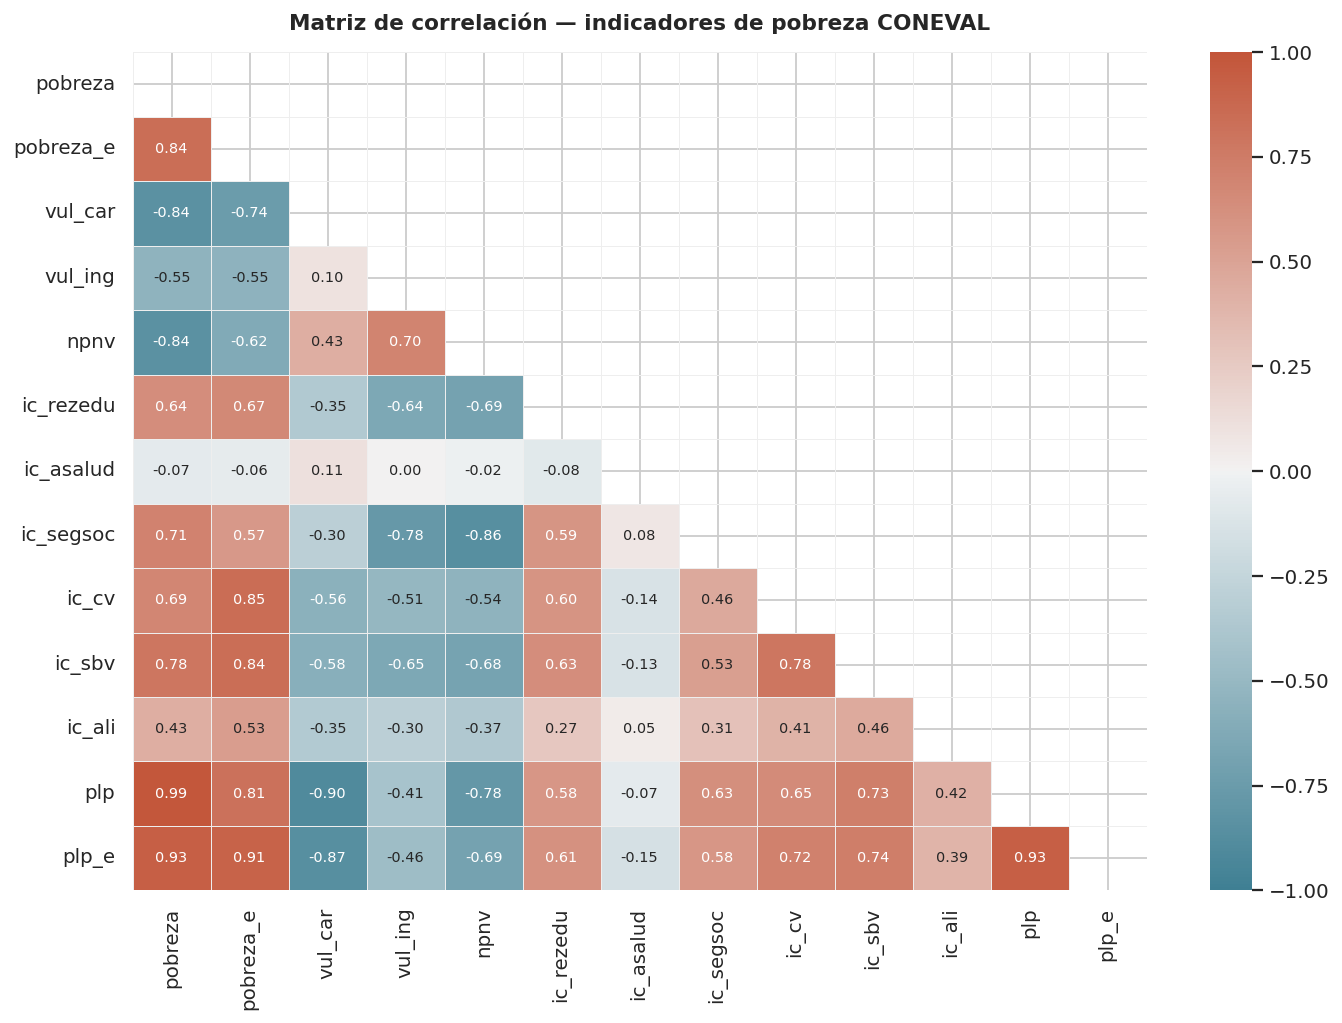

In [6]:
vars_corr = ["pobreza","pobreza_e","vul_car","vul_ing","npnv",
             "ic_rezedu","ic_asalud","ic_segsoc","ic_cv","ic_sbv","ic_ali","plp","plp_e"]

fig, ax = plt.subplots(figsize=(11, 8))
corr = df[vars_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=.4, linecolor="#eee",
            annot_kws={"size": 8}, ax=ax)

ax.set_title("Matriz de correlación — indicadores de pobreza CONEVAL",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_pob_03_correlacion.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Boxplots por entidad federativa (top 10 más pobres)

/tmp/ipykernel_24953/2638051940.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x="entidad_federativa", y="pobreza",
/tmp/ipykernel_24953/2638051940.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)


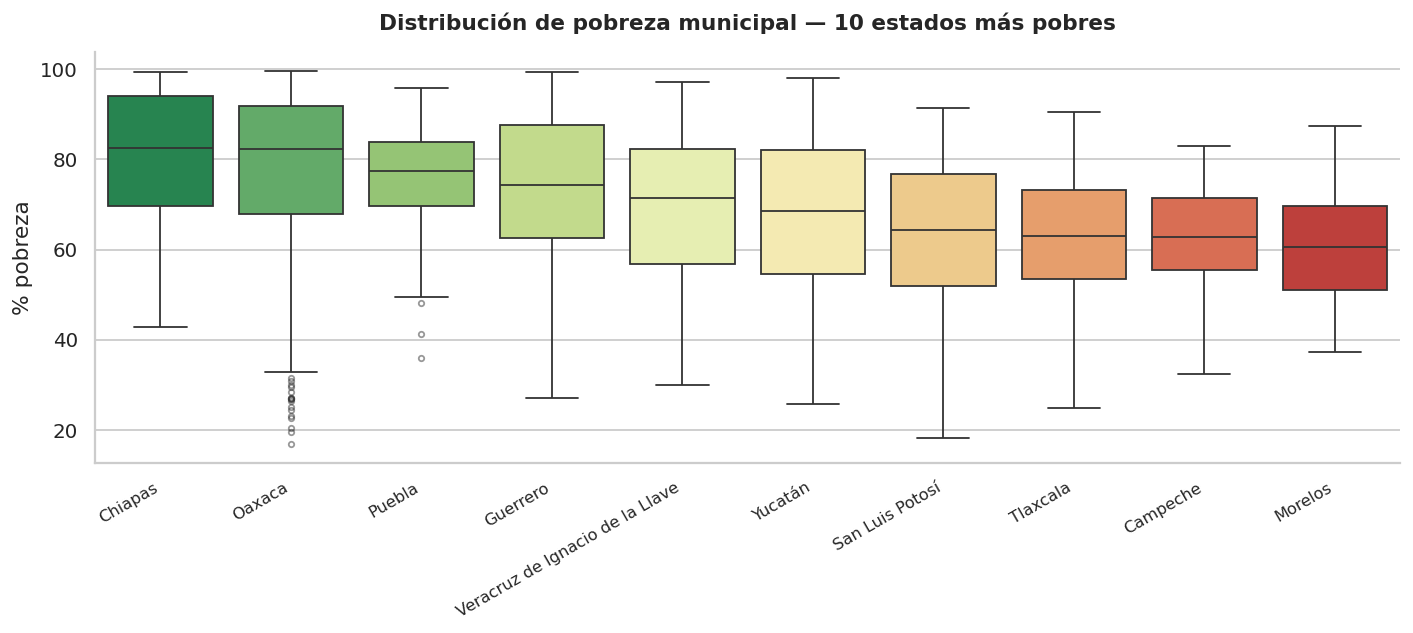

In [7]:
# Entidades con mayor pobreza media
top_ents = (df.groupby("entidad_federativa")["pobreza"]
              .mean().nlargest(10).index.tolist())
df_top = df[df["entidad_federativa"].isin(top_ents)].copy()

orden_ent = (df_top.groupby("entidad_federativa")["pobreza"]
               .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_top, x="entidad_federativa", y="pobreza",
            order=orden_ent, palette="RdYlGn_r",
            flierprops=dict(marker="o", markersize=3, alpha=0.5), ax=ax)

ax.set_xlabel("")
ax.set_ylabel("% pobreza")
ax.set_title("Distribución de pobreza municipal — 10 estados más pobres",
             fontweight="bold", pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_pob_04_boxplot_estados.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Análisis para Sonora (clave_entidad = 26)

Municipios en Sonora: 72

Resumen estadístico Sonora:


,pobreza,pobreza_e,ic_segsoc,ic_sbv,ic_ali
count,72.00,72.00,72.00,72.00,72.00
mean,34.22,4.77,58.39,10.57,16.76
std,12.88,4.80,14.39,13.21,10.18
min,9.70,0.00,22.20,0.10,1.20
25%,24.48,1.80,49.58,2.65,8.65
50%,31.95,3.35,60.55,5.20,14.90
75%,41.32,5.75,68.55,12.42,21.35
max,74.80,27.80,86.20,56.90,47.80


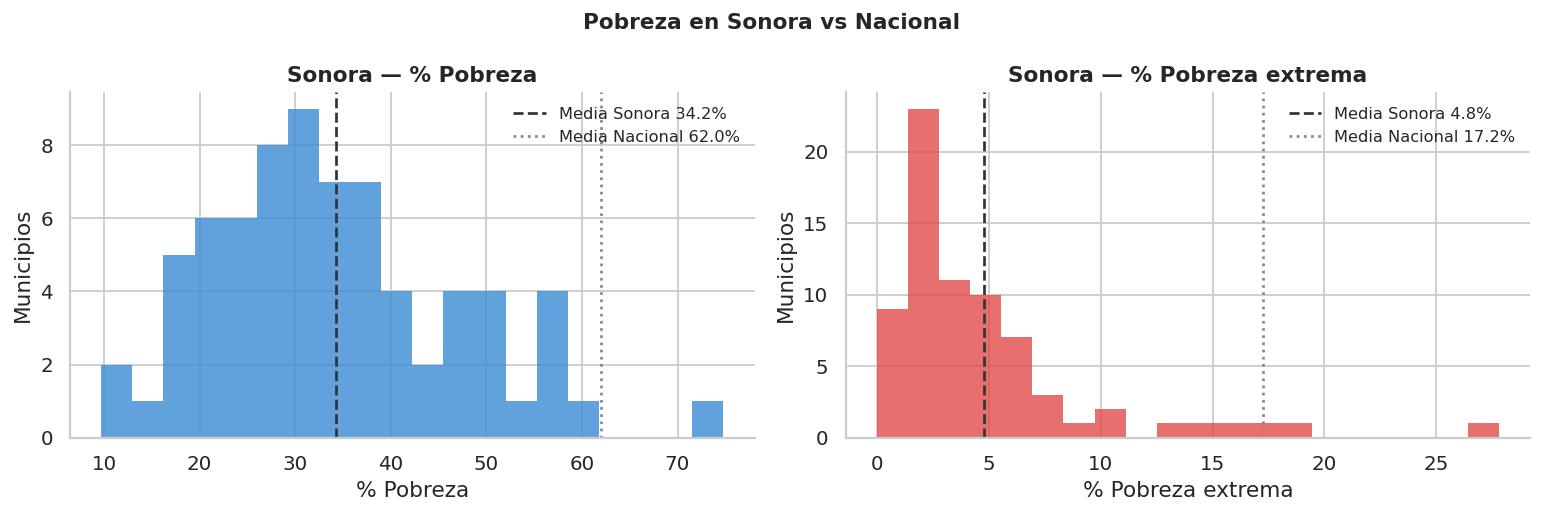

In [8]:
son = df[df["clave_entidad"] == 26].copy()
print(f"Municipios en Sonora: {len(son)}")
print(f"\nResumen estadístico Sonora:")
stats_son = son[["pobreza","pobreza_e","ic_segsoc","ic_sbv","ic_ali"]].describe().round(2)
display(stats_son)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label, color in zip(
    axes,
    ["pobreza", "pobreza_e"],
    ["% Pobreza", "% Pobreza extrema"],
    ["#3B8BD4", "#E24B4A"]
):
    ax.hist(son[col].dropna(), bins=20, color=color, edgecolor="none", alpha=0.8)
    ax.axvline(son[col].mean(),  color="#333", lw=1.5, ls="--",
               label=f"Media Sonora {son[col].mean():.1f}%")
    ax.axvline(df[col].mean(),   color="#888", lw=1.5, ls=":",
               label=f"Media Nacional {df[col].mean():.1f}%")
    ax.set_xlabel(label)
    ax.set_ylabel("Municipios")
    ax.set_title(f"Sonora — {label}", fontweight="bold")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Pobreza en Sonora vs Nacional", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_pob_05_sonora.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Top municipios más y menos pobres

In [9]:
cols_show = ["entidad_federativa","municipio","pobreza","pobreza_e","ic_segsoc"]
top5_mas   = df.nlargest(5, "pobreza")[cols_show].reset_index(drop=True)
top5_menos = df.nsmallest(5, "pobreza")[cols_show].reset_index(drop=True)

print("── 5 municipios con MAYOR pobreza ──")
display(top5_mas)
print("\n── 5 municipios con MENOR pobreza ──")
display(top5_menos)

# Sonora en el ranking nacional
rank = df["pobreza"].rank(ascending=False, method="min")
print("\n── Municipios de Sonora en ranking nacional ──")
son_rank = df[df["clave_entidad"]==26][["municipio","pobreza","pobreza_e"]].copy()
son_rank["rank_nacional"] = rank[son_rank.index].astype(int)
display(son_rank.sort_values("pobreza").head(10).reset_index(drop=True))

── 5 municipios con MAYOR pobreza ──


,entidad_federativa,municipio,pobreza,pobreza_e,ic_segsoc
0,Oaxaca,San Simón Zahuatlán,99.6,84.3,96.1
1,Guerrero,Cochoapa el Grande,99.4,84.2,97.0
2,Chiapas,San Juan Cancuc,99.3,65.6,85.0
3,Oaxaca,Coicoyán de las Flores,99.3,82.4,89.2
4,Oaxaca,San Francisco Teopan,99.3,44.1,79.0



── 5 municipios con MENOR pobreza ──


,entidad_federativa,municipio,pobreza,pobreza_e,ic_segsoc
0,Nuevo León,San Pedro Garza García,5.5,0.3,44.1
1,Nuevo León,Parás,7.3,0.2,66.9
2,Ciudad de México,Benito Juárez,7.9,0.3,32.6
3,Nuevo León,Agualeguas,8.7,0.4,62.3
4,Sonora,Huépac,9.7,0.0,40.2



── Municipios de Sonora en ranking nacional ──


,municipio,pobreza,pobreza_e,rank_nacional
0,Huépac,9.7,0.0,2462
1,Aconchi,11.0,1.1,2451
2,Baviácora,15.6,0.5,2436
3,San Felipe de Jesús,16.8,0.3,2427
4,Nacozari de García,18.3,1.8,2418
5,Soyopa,18.5,3.4,2416
6,Cumpas,19.2,0.6,2413
7,Banámichi,19.4,1.1,2411
8,Huásabas,19.7,1.1,2408
9,La Colorada,20.4,1.4,2403


## 9. Conclusiones del EDA — Pobreza

- **3 municipios con datos faltantes**: Seybaplaya (Campeche), Honduras de la Sierra (Chiapas), La Magdalena Tlaltelulco (Tlaxcala). Imputar con media estatal o excluir.
- La distribución de pobreza es aproximadamente **normal centrada en 62.7%** (mediana nacional).
- Pobreza extrema está **muy sesgada a la derecha**: la mayoría de municipios tiene menos de 20%, pero algunos superan el 80%.
- **Seguridad social** (72.4%) es la carencia más extendida; **calidad de vivienda** (16.3%) la menos prevalente.
- Los municipios más pobres se concentran en **Oaxaca, Guerrero y Chiapas**.
- **Sonora** está muy por debajo de la media nacional: 34.2% vs 62.0%.
- `ic_segsoc` y `plp` tienen altísima correlación con `pobreza` (>0.9) — evitar incluir ambas en el modelo por **multicolinealidad**.
- Para el modelo usar preferentemente: `pobreza`, `pobreza_e`, `ic_rezedu`, `ic_sbv`, `ic_ali` como variables independientes.
- Construir **CVEGEO** = `clave_entidad` (zfill 2) + `clave_municipio` (zfill 3) para el merge.